In [335]:
from datascience import *
import numpy as np

%matplotlib inline

import matplotlib.pyplot as plt

In [336]:
united = Table.read_table("united.csv")
united = united.with_column("Row", np.arange(united.num_rows)).move_to_start("Row")
united.show(5)

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64


In [337]:
np.median(united.column("Delay"))
united.num_rows

13825

In [338]:
np.median(united.sample(1000).column("Delay"))

2.0

In [339]:
res = make_array()
def calc_median(n):
    return np.median(united.sample(n).column("Delay"))

In [340]:
for i in range(2000):
    res = np.append(res, calc_median(100))

In [341]:
median_res_100 = Table().with_column("Medians", res)
median_res_100

Medians
0
3.5
1
3
5
2.5
3
1.5
3
1


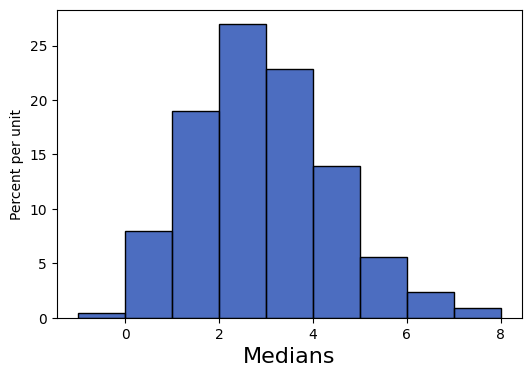

In [342]:
median_res_100.hist(bins=np.arange(-1, 9, 1))

In [343]:
# Swain vs Alabama
pop_props = make_array(0.26, 0.74)
pop_props

array([ 0.26,  0.74])

In [344]:
sample_proportions(100, pop_props)

array([ 0.23,  0.77])

In [345]:
def panel_props():
    return sample_proportions(100, pop_props).item(0)

In [346]:
panels = make_array()

for i in range(10000):
    new_panel = panel_props()*100
    panels = np.append(panels, new_panel)

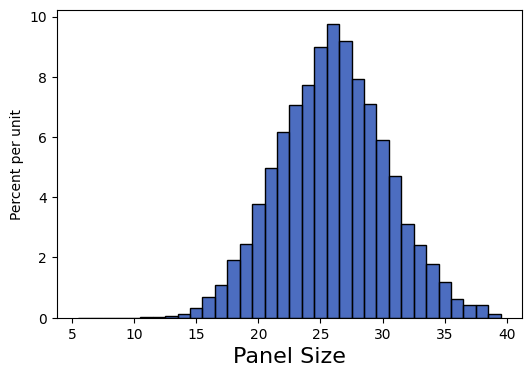

In [347]:
panels_tab = Table().with_column("Panel Size", panels).hist(bins=np.arange(5.5, 40.5, 1))

In [348]:
# Mendel and Pea Flowers

predicted_props = make_array(0.75, 0.25)
observed_purples = 709 / 929
observed_purples

0.7631862217438106

In [349]:
sample_proportions(929, predicted_props)

array([ 0.73950484,  0.26049516])

In [350]:
def purples_flowers():
    return sample_proportions(929, predicted_props).item(0) * 100

In [351]:
purples = make_array()

for i in range(10_000):
    purples = np.append(purples, purples_flowers())

purples

array([ 76.96447793,  75.34983854,  75.88805167, ...,  75.34983854,
        76.10333692,  75.67276642])

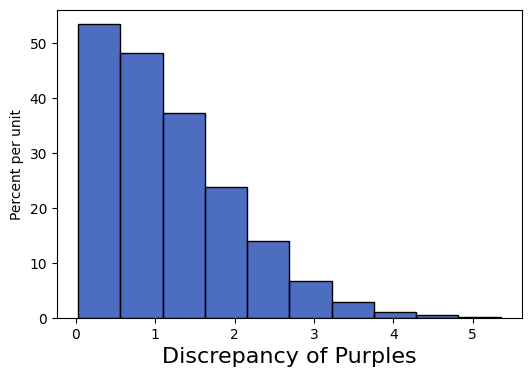

In [352]:

# Table().with_column("Panel Size", panels).hist(bins=np.arange(5.5, 40.5, 1))
Table().with_column("Discrepancy of Purples", np.abs(purples - 75)).hist()